# **Data Transformation**

1. Connect to PosgreSQL source and View definition
2. Check Duplicates
3. Replace NULL to Date
4. Filter the DataSet
5. Create a new derived column
6. Aggregate data by Age Group

In [3]:
#Connect to PostgreSQL server
import pandas as pd
from sqlalchemy import create_engine
import os

os.environ["PG_URL"] = (
        "postgresql+psycopg2://neondb_owner:npg_2wdZpRaF0LmG@"
        "ep-patient-dawn-advbhv1g-pooler.c-2.us-east-1.aws.neon.tech/"
        "neondb?sslmode=require"
    )

engine = create_engine(os.environ["PG_URL"], pool_pre_ping=True)

In [4]:
#Connect to dataset and view the table definition
df = pd.read_sql("SELECT * FROM covid_case_surveillance", engine)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11240 entries, 0 to 11239
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   case_month            11240 non-null  object
 1   cdc_case_earliest_dt  0 non-null      object
 2   res_state             11240 non-null  object
 3   age_group             11240 non-null  object
 4   sex                   11240 non-null  object
 5   race                  11240 non-null  object
 6   ethnicity             11240 non-null  object
 7   death_yn              11240 non-null  object
 8   hosp_yn               11240 non-null  object
 9   icu_yn                11240 non-null  object
 10  medcond_yn            11240 non-null  object
dtypes: object(11)
memory usage: 966.1+ KB


In [5]:
#Preview sample data
display(df.head())

,case_month,cdc_case_earliest_dt,res_state,age_group,sex,race,ethnicity,death_yn,hosp_yn,icu_yn,medcond_yn
0,2022-01,None,IL,18 to 49 years,Female,White,Non-Hispanic/Latino,Missing,Missing,Missing,Unknown
1,2022-12,None,NY,65+ years,Female,White,Non-Hispanic/Latino,Missing,Missing,Missing,Unknown
2,2021-01,None,NJ,0 - 17 years,Female,White,Hispanic/Latino,No,No,Missing,Unknown
3,2022-01,None,NY,50 to 64 years,Male,Black,Non-Hispanic/Latino,No,No,Missing,Unknown
4,2021-11,None,UT,0 - 17 years,Female,White,Non-Hispanic/Latino,No,No,Missing,Unknown


In [37]:
#Convert the case_month to DateTime data types
df['case_month'] = pd.to_datetime(df['case_month'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11240 entries, 0 to 11239
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   case_month            11240 non-null  datetime64[ns]
 1   cdc_case_earliest_dt  0 non-null      object        
 2   res_state             11240 non-null  object        
 3   age_group             11240 non-null  object        
 4   sex                   11240 non-null  object        
 5   race                  11240 non-null  object        
 6   ethnicity             11240 non-null  object        
 7   death_yn              11240 non-null  object        
 8   hosp_yn               11240 non-null  object        
 9   icu_yn                11240 non-null  object        
 10  medcond_yn            11240 non-null  object        
dtypes: datetime64[ns](1), object(10)
memory usage: 966.1+ KB


In [6]:
#Check duplicates
print(df.isnull().sum())

case_month                  0
cdc_case_earliest_dt    11240
res_state                   0
age_group                   0
sex                         0
race                        0
ethnicity                   0
death_yn                    0
hosp_yn                     0
icu_yn                      0
medcond_yn                  0
dtype: int64


In [39]:
#Replace NULL with 1900-01 for Case Earliest Date
df['cdc_case_earliest_dt'] = df['cdc_case_earliest_dt'].fillna('1900-01-01')
df.head()

,case_month,cdc_case_earliest_dt,res_state,age_group,sex,race,ethnicity,death_yn,hosp_yn,icu_yn,medcond_yn
0,2022-01-01,1900-01-01,IL,18 to 49 years,Female,White,Non-Hispanic/Latino,Missing,Missing,Missing,Unknown
1,2022-12-01,1900-01-01,NY,65+ years,Female,White,Non-Hispanic/Latino,Missing,Missing,Missing,Unknown
2,2021-01-01,1900-01-01,NJ,0 - 17 years,Female,White,Hispanic/Latino,No,No,Missing,Unknown
3,2022-01-01,1900-01-01,NY,50 to 64 years,Male,Black,Non-Hispanic/Latino,No,No,Missing,Unknown
4,2021-11-01,1900-01-01,UT,0 - 17 years,Female,White,Non-Hispanic/Latino,No,No,Missing,Unknown


In [40]:
#Filter the dataset to show rows where age_group is 'NA' or 'Missing'
df_missing_age_group = df[df['age_group'].isin(['NA', 'Missing'])]

#Display the first 10 rows of the filtered DataFrame
display(df_missing_age_group.head(20))

,case_month,cdc_case_earliest_dt,res_state,age_group,sex,race,ethnicity,death_yn,hosp_yn,icu_yn,medcond_yn
336,2023-03-01,1900-01-01,MA,NA,NA,NA,NA,Missing,Missing,Missing,Unknown
366,2023-03-01,1900-01-01,MA,NA,NA,NA,NA,NA,No,Missing,Unknown
627,2021-04-01,1900-01-01,MO,NA,NA,NA,NA,Unknown,Unknown,Missing,Unknown
639,2022-01-01,1900-01-01,NJ,Missing,Female,Unknown,Missing,No,No,Missing,Unknown
809,2022-01-01,1900-01-01,NJ,Missing,Female,Unknown,Missing,No,Missing,Missing,Unknown
1085,2020-10-01,1900-01-01,OR,NA,NA,NA,NA,NA,No,Missing,Unknown
1181,2022-06-01,1900-01-01,OR,NA,NA,NA,NA,Unknown,Unknown,Missing,Unknown
1229,2020-10-01,1900-01-01,OR,NA,NA,NA,NA,NA,Yes,No,Unknown
1231,2020-10-01,1900-01-01,OR,NA,NA,NA,NA,NA,Unknown,Missing,Unknown
1305,2022-06-01,1900-01-01,OR,NA,NA,NA,NA,NA,Unknown,Missing,Unknown


In [11]:
# Create a new column by combining race and ethnicity
df['race_ethnicity'] = df['race'] + ', ' + df['ethnicity']

# Display the first few rows to verify the new column
display(df.head())

,case_month,cdc_case_earliest_dt,res_state,age_group,sex,race,ethnicity,death_yn,hosp_yn,icu_yn,medcond_yn,race_ethnicity
0,2022-01,None,IL,18 to 49 years,Female,White,Non-Hispanic/Latino,Missing,Missing,Missing,Unknown,"White, Non-Hispanic/Latino"
1,2022-12,None,NY,65+ years,Female,White,Non-Hispanic/Latino,Missing,Missing,Missing,Unknown,"White, Non-Hispanic/Latino"
2,2021-01,None,NJ,0 - 17 years,Female,White,Hispanic/Latino,No,No,Missing,Unknown,"White, Hispanic/Latino"
3,2022-01,None,NY,50 to 64 years,Male,Black,Non-Hispanic/Latino,No,No,Missing,Unknown,"Black, Non-Hispanic/Latino"
4,2021-11,None,UT,0 - 17 years,Female,White,Non-Hispanic/Latino,No,No,Missing,Unknown,"White, Non-Hispanic/Latino"


In [7]:
#Count the number of cases by 'age_group'
age_group_cases = df['age_group'].value_counts()
print("\nHospitalization by Age Group Summary")
# Display the counts
display(age_group_cases)


Hospitalization by Age Group Summary


,count
age_group,
18 to 49 years,4438
65+ years,2336
50 to 64 years,2263
0 - 17 years,1793
NA,308
Missing,102


# **Data Visualization**

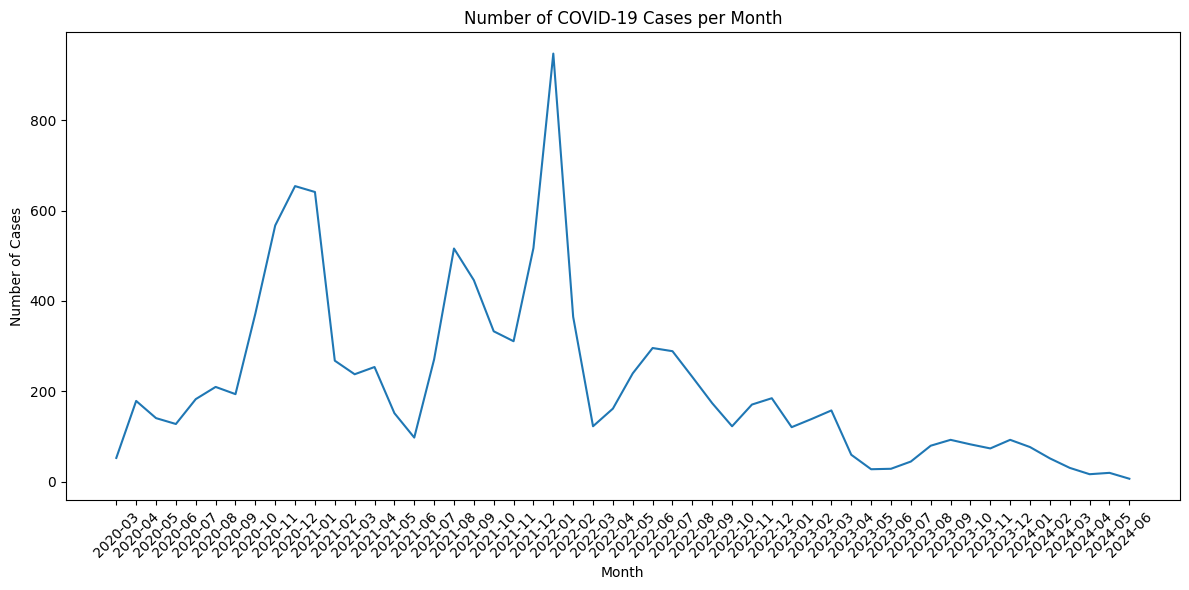

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a time series plot to visualize Number of Case by Month 'case_month'
monthly_cases = df['case_month'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_cases.index, y=monthly_cases.values)
plt.title('Number of COVID-19 Cases per Month')
plt.xlabel('Month')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

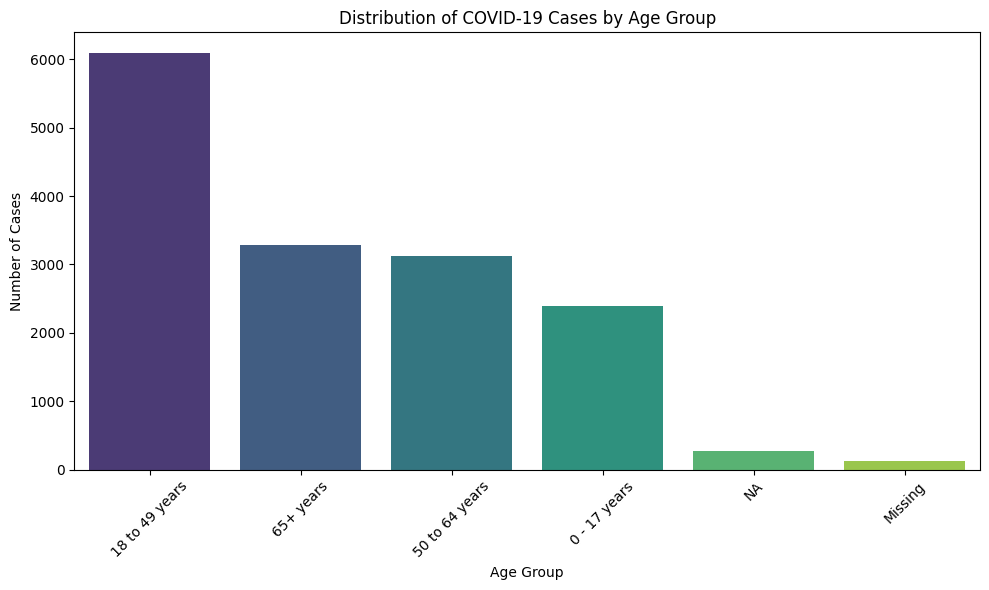

In [22]:
#Create a bar plot by Age Group counts
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_cases.index, y=age_group_cases.values, hue=age_group_cases.index, palette='viridis', legend=False)
plt.title('Distribution of COVID-19 Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

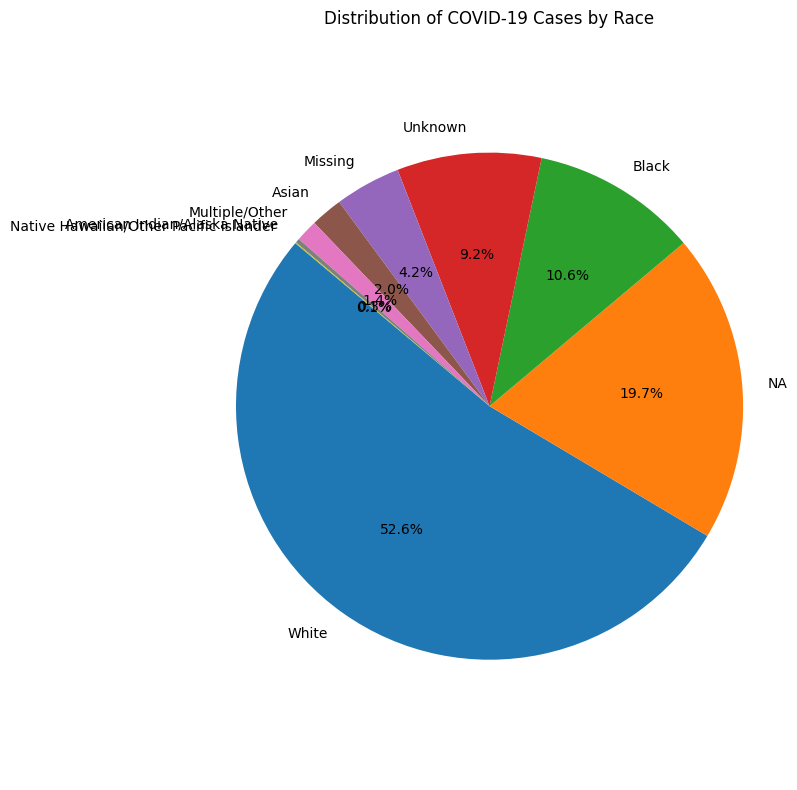

In [23]:
#Pie Chart to show the number of  occurrences of each race
race_counts = df['race'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(race_counts, labels=race_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of COVID-19 Cases by Race')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

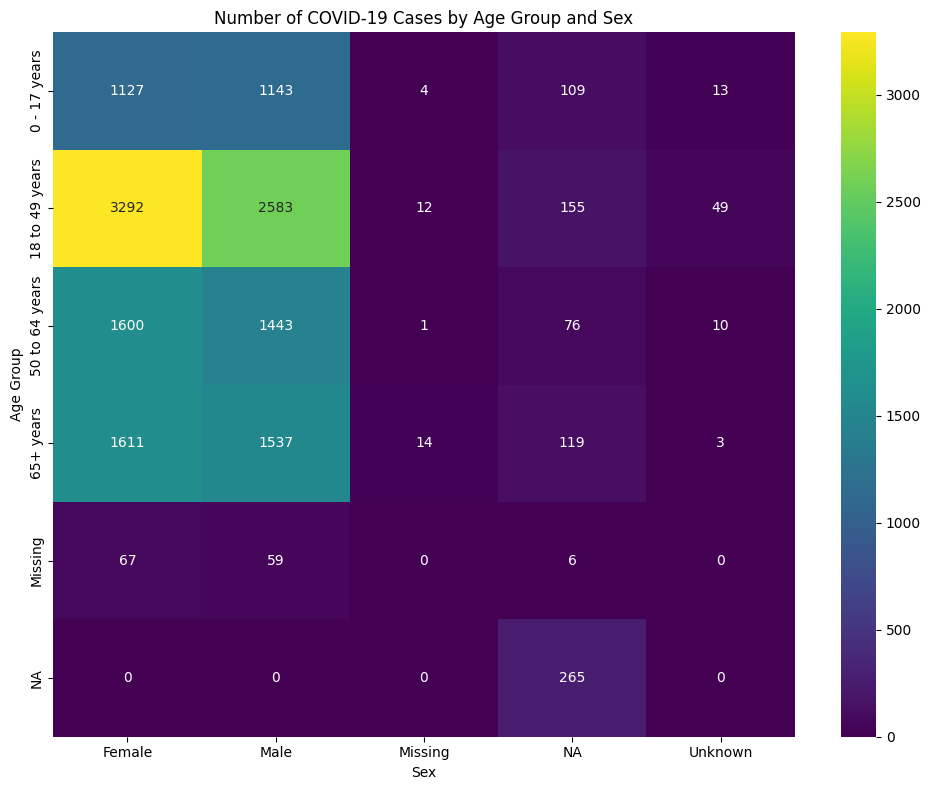

In [25]:
# Group by 'age_group' and 'sex' and count the number of cases
age_sex_cases = df.groupby(['age_group', 'sex']).size().unstack(fill_value=0)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(age_sex_cases, annot=True, fmt='d', cmap='viridis')
plt.title('Number of COVID-19 Cases by Age Group and Sex')
plt.xlabel('Sex')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

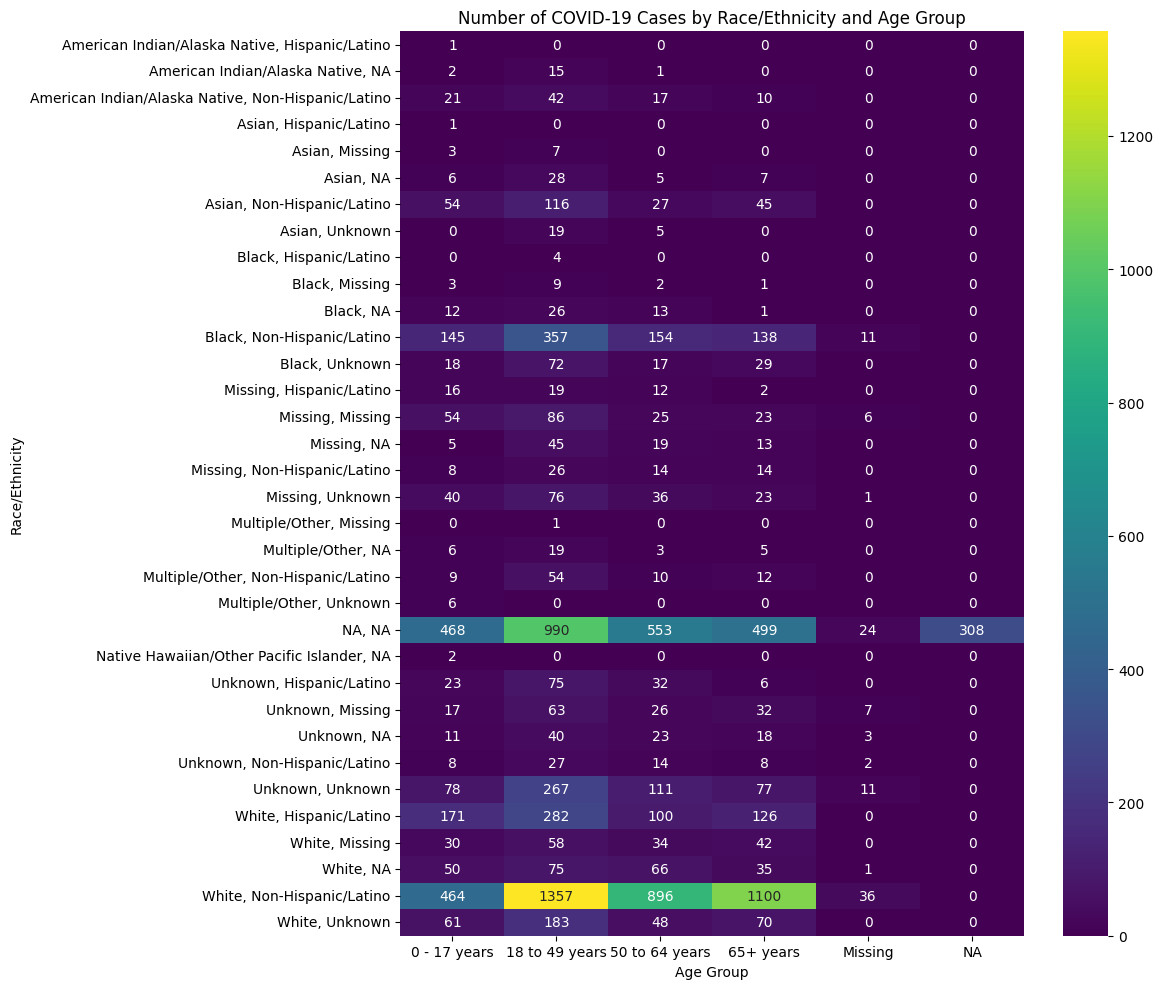

In [13]:
# Group by 'race_ethnicity' and 'age_group' and count the number of cases
race_ethnicity_age_cases = df.groupby(['race_ethnicity', 'age_group']).size().unstack(fill_value=0)

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(race_ethnicity_age_cases, annot=True, fmt='d', cmap='viridis')
plt.title('Number of COVID-19 Cases by Race/Ethnicity and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Race/Ethnicity')
plt.tight_layout()
plt.show()

In [26]:
# Summarize death outcomes - TEMP section to check the agg across some fields
death_counts = df['race'].value_counts()
print("Death Outcomes Summary:")
display(death_counts)

Death Outcomes Summary:


,count
race,
White,8041
NA,3010
Black,1618
Unknown,1408
Missing,642
Asian,312
Multiple/Other,215
American Indian/Alaska Native,42
Native Hawaiian/Other Pacific Islander,10


In [28]:
import os

# Get the current working directory
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# List files in the current directory to find the notebook file
print("Files in current directory:")
for file in os.listdir(current_dir):
  print(file)

Current directory: /content
Files in current directory:
.config
sample_data
